In [ ]:
# Install required packages
!pip install xgboost scikit-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from scipy.sparse import hstack
import re

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
from google.colab import files
import io

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))


Saving Email_Data.csv to Email_Data.csv


In [ ]:
def clean_text(text):
    """Remove foreign characters and normalize whitespace."""
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Remove non-ASCII characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Apply cleaning
print("Cleaning text data...")
df['cleaned_text'] = df['text'].apply(clean_text)

print(f"✓ Text cleaning complete!")
print(f"\nExample:")
print(f"Original: {df['text'].iloc[0][:100]}...")
print(f"Cleaned:  {df['cleaned_text'].iloc[0][:100]}...")

Cleaning text data...
✓ Text cleaning complete!

Example:
Original: Hi

                I am running the IR test program from Max Davies. To do this I need to start
IC ...
Cleaned:  Hi I am running the IR test program from Max Davies. To do this I need to start IC with thw wizard o...


In [ ]:
def extract_text_features(text):
    """Extract numerical features from text."""
    if pd.isna(text) or text == "":
        return {
            'word_count': 0,
            'char_count': 0,
            'avg_word_length': 0,
            'punctuation_ratio': 0,
            'capital_ratio': 0,
            'exclamation_count': 0,
            'question_count': 0,
            'url_count': 0,
            'money_symbol_count': 0,
            'urgency_words': 0
        }

    words = text.split()

    features = {
        'word_count': len(words),
        'char_count': len(text),
        'avg_word_length': np.mean([len(word) for word in words]) if words else 0,
        'punctuation_ratio': sum(c in '.,!?;:' for c in text) / len(text) if len(text) > 0 else 0,
        'capital_ratio': sum(c.isupper() for c in text) / len(text) if len(text) > 0 else 0,
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
        'url_count': len(re.findall(r'http[s]?://|www\.', text.lower())),
        'money_symbol_count': text.count('$') + text.count('€') + text.count('£'),
        'urgency_words': sum(word in text.lower() for word in
                           ['urgent', 'immediately', 'act now', 'limited time', 'expires', 'hurry'])
    }

    return features

# Extract features
print("Extracting text features...")
text_features_df = df['cleaned_text'].apply(extract_text_features).apply(pd.Series)

print(f"✓ Text features extracted!")
print(f"\nFeatures created: {text_features_df.columns.tolist()}")
print(f"\nFeature statistics:")
display(text_features_df.describe())

Extracting text features...
✓ Text features extracted!

Features created: ['word_count', 'char_count', 'avg_word_length', 'punctuation_ratio', 'capital_ratio', 'exclamation_count', 'question_count', 'url_count', 'money_symbol_count', 'urgency_words']

Feature statistics:


,word_count,char_count,avg_word_length,punctuation_ratio,capital_ratio,exclamation_count,question_count,url_count,money_symbol_count,urgency_words
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000
mean,198.550250,1409.593500,5.937594,0.026087,0.046073,0.854500,0.77450,1.883250,0.695500,0.148000
std,479.709803,3707.023529,2.099048,0.015434,0.047740,5.615756,4.16323,20.100289,11.286502,0.387471
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,69.000000,466.000000,5.322581,0.018519,0.024805,0.000000,0.00000,0.000000,0.000000,0.000000
50%,97.000000,644.000000,5.682810,0.022590,0.032598,0.000000,0.00000,1.000000,0.000000,0.000000
75%,152.000000,1020.000000,6.092252,0.029129,0.050304,0.000000,0.00000,1.000000,0.000000,0.000000
max,5926.000000,47300.000000,52.415094,0.333333,0.714286,177.000000,123.00000,842.000000,461.000000,2.000000


In [ ]:
# Initialize TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Limit to top 5000 features
    ngram_range=(1, 2),     # Use unigrams and bigrams
    min_df=2,                # Ignore terms that appear in less than 2 documents
    max_df=0.95,             # Ignore terms that appear in more than 95% of documents
    strip_accents='unicode',
    lowercase=True,
    analyzer='word',
    token_pattern=r'\w{2,}', # Words with at least 2 characters
    stop_words='english'
)

# Fit and transform
print("Creating TF-IDF features...")
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

print(f"✓ TF-IDF features created!")
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Matrix sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100:.2f}%")

Creating TF-IDF features...
✓ TF-IDF features created!
TF-IDF matrix shape: (4000, 5000)
Matrix sparsity: 98.70%


In [ ]:
# Combine TF-IDF with text features
print("Combining all features...")

# Convert text features to numpy array
text_features_array = text_features_df.values

# Combine sparse TF-IDF with dense text features
X = hstack([tfidf_matrix, text_features_array])

print(f"✓ Combined feature matrix shape: {X.shape}")

# Encode target labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label_specific'])

print(f"\n✓ Target variable encoded!")
print(f"Label mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {label} → {i}")

print(f"\nClass distribution:")
unique, counts = np.unique(y, return_counts=True)
for label_idx, count in zip(unique, counts):
    print(f"  {label_encoder.classes_[label_idx]}: {count} ({count/len(y)*100:.1f}%)")

Combining all features...
✓ Combined feature matrix shape: (4000, 5010)

✓ Target variable encoded!
Label mapping:
  human_legit → 0
  human_phishing → 1
  llm_legit → 2
  llm_phishing → 3

Class distribution:
  human_legit: 1000 (25.0%)
  human_phishing: 1000 (25.0%)
  llm_legit: 1000 (25.0%)
  llm_phishing: 1000 (25.0%)


In [ ]:
# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set distribution:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for label_idx, count in zip(unique_train, counts_train):
    print(f"  {label_encoder.classes_[label_idx]}: {count}")

print(f"\nTest set distribution:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for label_idx, count in zip(unique_test, counts_test):
    print(f"  {label_encoder.classes_[label_idx]}: {count}")

Training set size: 3200 samples
Test set size: 800 samples

Training set distribution:
  human_legit: 800
  human_phishing: 800
  llm_legit: 800
  llm_phishing: 800

Test set distribution:
  human_legit: 200
  human_phishing: 200
  llm_legit: 200
  llm_phishing: 200


In [ ]:
# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',  # Multi-class classification
    num_class=len(label_encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss',
    early_stopping_rounds=10
)

print("Training XGBoost model...")
print("="*50)

# Create sample weights
sample_weights = np.ones(len(y_train))
sample_weights[y_train == label_encoder.transform(['human_phishing'])[0]] = 2.0  # 2x weight
sample_weights[y_train == label_encoder.transform(['llm_phishing'])[0]] = 2.0    # 2x weight

# Train with evaluation set
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=20
)

print("\n✓ Model training complete!")

Training XGBoost model...
[0]	validation_0-mlogloss:1.23369
[20]	validation_0-mlogloss:0.26207
[40]	validation_0-mlogloss:0.10158
[60]	validation_0-mlogloss:0.05723
[80]	validation_0-mlogloss:0.03971
[100]	validation_0-mlogloss:0.03093
[120]	validation_0-mlogloss:0.02672
[140]	validation_0-mlogloss:0.02438
[160]	validation_0-mlogloss:0.02327
[180]	validation_0-mlogloss:0.02276
[199]	validation_0-mlogloss:0.02218

✓ Model training complete!


In [ ]:
# Make predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("="*50)
print("MODEL PERFORMANCE")
print("="*50)
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Difference: {train_accuracy - test_accuracy:.4f}")

print("\n" + "="*50)
print("CLASSIFICATION REPORT (Test Set)")
print("="*50)
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))

MODEL PERFORMANCE
Training Accuracy: 0.9994
Test Accuracy: 0.9962
Difference: 0.0031

CLASSIFICATION REPORT (Test Set)
                precision    recall  f1-score   support

   human_legit       0.99      0.99      0.99       200
human_phishing       0.99      0.99      0.99       200
     llm_legit       1.00      0.99      1.00       200
  llm_phishing       1.00      1.00      1.00       200

      accuracy                           1.00       800
     macro avg       1.00      1.00      1.00       800
  weighted avg       1.00      1.00      1.00       800



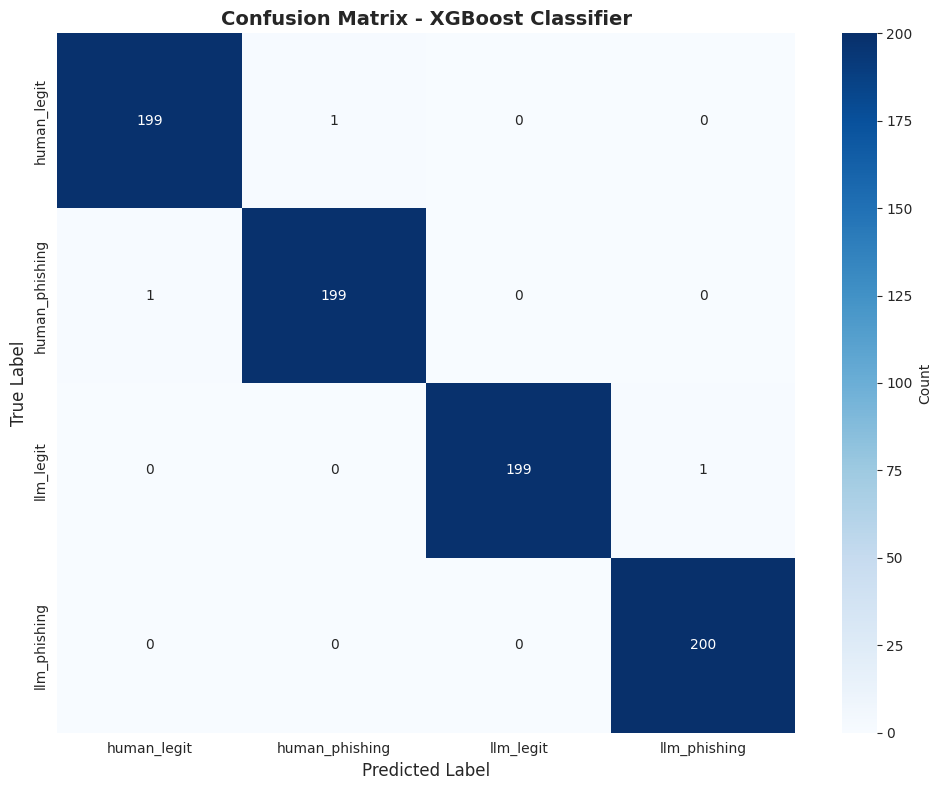


Per-class Accuracy:
  human_legit: 0.9950
  human_phishing: 0.9950
  llm_legit: 0.9950
  llm_phishing: 1.0000


In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

# Plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - XGBoost Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate per-class accuracy
print("\nPer-class Accuracy:")
for i, label in enumerate(label_encoder.classes_):
    class_accuracy = cm[i, i] / cm[i, :].sum()
    print(f"  {label}: {class_accuracy:.4f}")

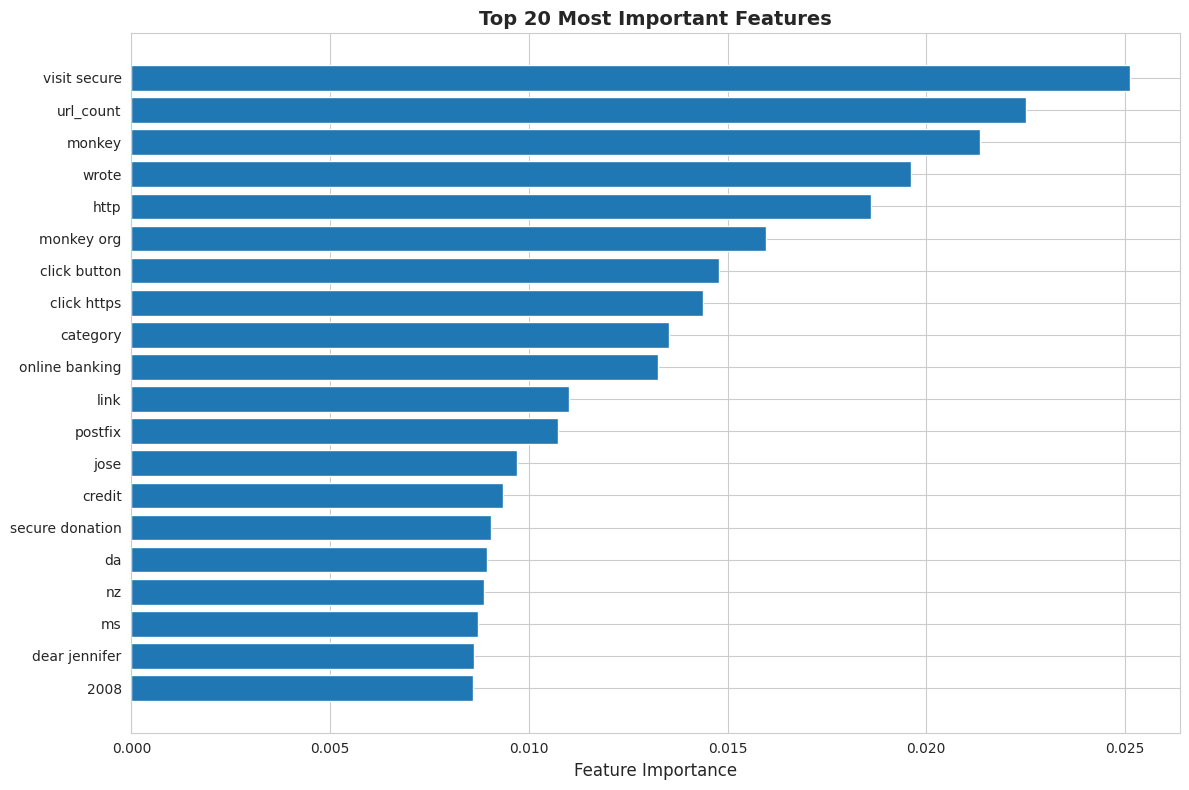


Top 10 Most Important Features:
 1. visit secure                   - 0.025130
 2. url_count                      - 0.022524
 3. monkey                         - 0.021357
 4. wrote                          - 0.019608
 5. http                           - 0.018602
 6. monkey org                     - 0.015973
 7. click button                   - 0.014782
 8. click https                    - 0.014389
 9. category                       - 0.013534
10. online banking                 - 0.013246


In [ ]:
# Get feature importance
feature_importance = xgb_model.feature_importances_

# Create feature names (TF-IDF features + text stat features)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
text_stat_names = text_features_df.columns.tolist()
all_feature_names = list(tfidf_feature_names) + text_stat_names

# Get top 20 most important features
top_n = 20
top_indices = np.argsort(feature_importance)[-top_n:][::-1]
top_features = [all_feature_names[i] for i in top_indices]
top_importance = feature_importance[top_indices]

# Plot
plt.figure(figsize=(12, 8))
plt.barh(range(len(top_features)), top_importance)
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Feature Importance', fontsize=12)
plt.title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
for i, (feature, importance) in enumerate(zip(top_features[:10], top_importance[:10]), 1):
    print(f"{i:2d}. {feature:30s} - {importance:.6f}")

In [ ]:
# Create a fresh model without early stopping for cross-validation
xgb_model_cv = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
    # NOTE: No early_stopping_rounds for cross-validation
)

# Perform cross-validation
print("Performing 5-fold cross-validation...")
cv_scores = cross_val_score(xgb_model_cv, X_train, y_train, cv=5, scoring='accuracy', verbose=1)

print("\n" + "="*50)
print("CROSS-VALIDATION RESULTS")
print("="*50)
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std CV Accuracy: {cv_scores.std():.4f}")

Performing 5-fold cross-validation...

CROSS-VALIDATION RESULTS
CV Scores: [0.9765625 0.978125  0.978125  0.9890625 0.9796875]
Mean CV Accuracy: 0.9803
Std CV Accuracy: 0.0045


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  1.9min finished
